Cleared 1 old image file(s) before regenerating.

Tab 6 Corrected Model Configuration
  Material              : Aluminium 6061-T6
  Process               : spray
  Joint Type            : Lap joint
  Weld Arrangement      : Double fillet weld on both longitudinal edges of the overlap
  Plate Length          : 200 mm
  Plate Width           : 80 mm
  Plate Thickness       : 4 mm
  Assembly Width        : 135 mm
  Overlap               : 25 mm
  Fillet Leg            : 4 mm
  Weld Length           : 200 mm
  Weld-Line Y Positions : [55. 80.] mm
  Thermocouple Distances: [ 2.  5. 10.] mm


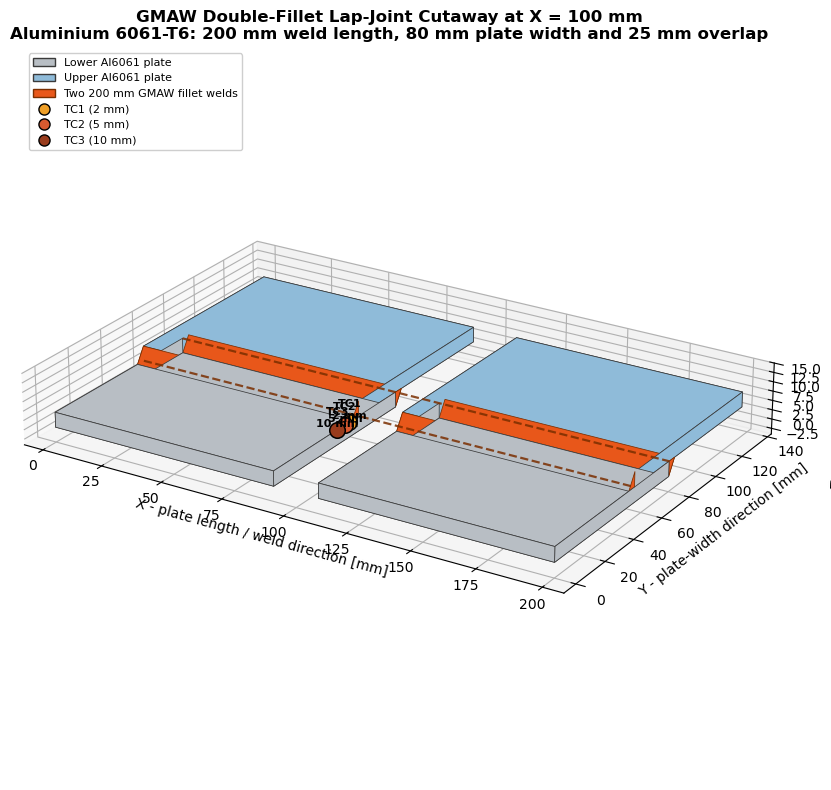


Saved corrected lap-joint cutaway: lapjoint_cutaway.png


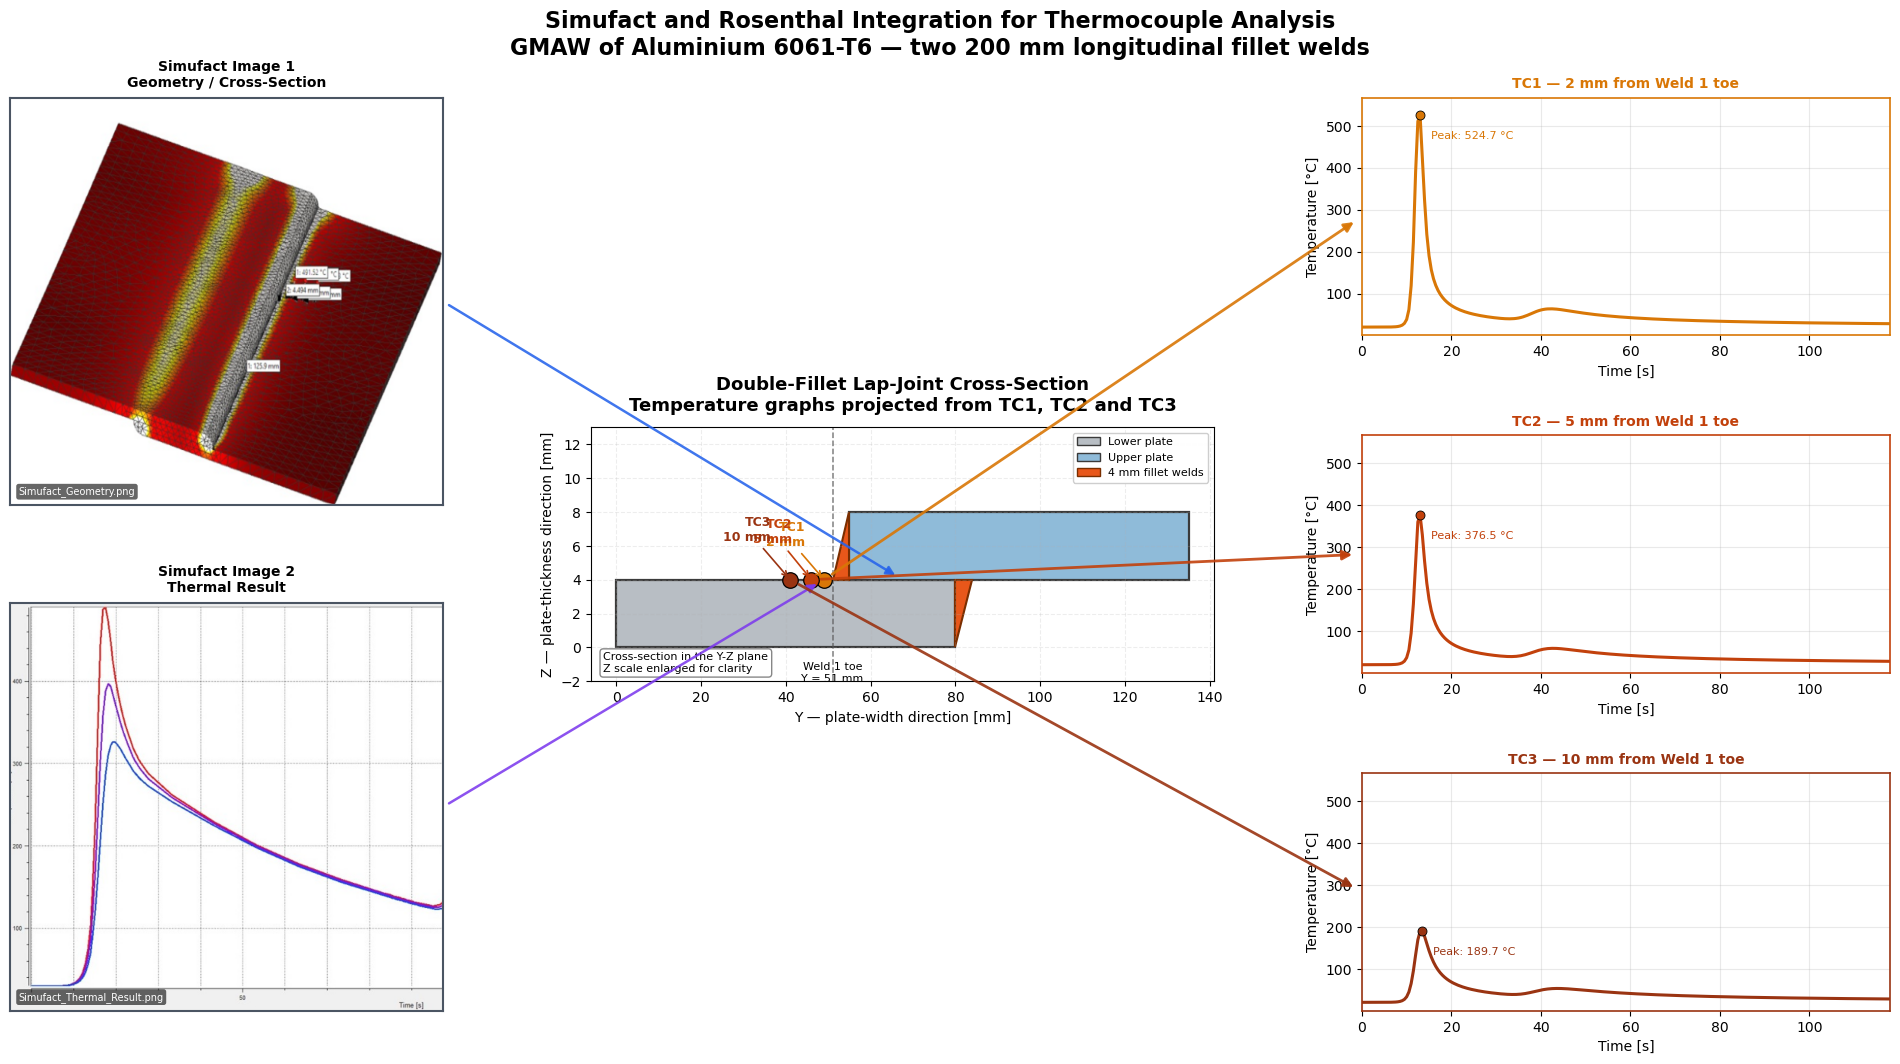


Saved sensor-projected temperature-vs-time figure: Simufact Rosenthal Cross-Section Integration.png

Visualization metadata written to project_core.asdf under 'visualization_data'.

Generated File Check
  ✓ lapjoint_cutaway.png
  ✓ Simufact Rosenthal Cross-Section Integration.png

Tab 6 completed successfully.


In [3]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import (
    Patch,
    Rectangle,
    Polygon,
    ConnectionPatch,
)
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from weldx import WeldxFile


# ============================================================
# PROJECT FILE
# ============================================================
CORE_FILE = "project_core.asdf"

if not Path(CORE_FILE).exists():
    raise FileNotFoundError(
        f"⚠ {CORE_FILE} not found. Run Tabs 1 to 5 first!"
    )


# ============================================================
# LOAD THE SHARED WELDX PROJECT
# ============================================================
with WeldxFile(CORE_FILE, mode="r") as wx:
    core = wx.copy()


required_keys = [
    "material",
    "geometry",
    "gmaw_process",
    "process",
    "monte_carlo",
    "thermal_results",
]

missing_keys = [
    key
    for key in required_keys
    if key not in core
]

if missing_keys:
    raise KeyError(
        f"Missing required data in {CORE_FILE}: {missing_keys}. "
        "Run Tabs 1 to 5 again in order."
    )


material_core = core["material"]
geometry_core = core["geometry"]
thermal_core = core["thermal_results"]
gmaw_process = core["gmaw_process"]


# ============================================================
# MATERIAL, PROCESS AND PLATE PARAMETERS
# ============================================================
material_name = str(
    material_core["common_name"]
)

joint_type = str(
    geometry_core["joint_type"]
)

joint_configuration = str(
    geometry_core["joint_configuration"]
)

plate_length_mm = float(
    geometry_core["plate_length"].to("mm").m
)

plate_width_mm = float(
    geometry_core["plate_width"].to("mm").m
)

plate_thickness_mm = float(
    geometry_core["plate_thickness"].to("mm").m
)

overlap_mm = float(
    geometry_core["overlap"].to("mm").m
)

fillet_leg_mm = float(
    geometry_core["fillet_leg"].to("mm").m
)

sensor_labels = [
    str(label)
    for label in geometry_core["sensor_labels"]
]

sensor_distances_mm = np.asarray(
    geometry_core["thermo_distance"].to("mm").m,
    dtype=float,
)


# ============================================================
# VERIFY THE REQUIRED CONFIGURATION
# ============================================================
expected_values = {
    "plate length": (
        plate_length_mm,
        200.0,
    ),
    "plate width": (
        plate_width_mm,
        80.0,
    ),
    "plate thickness": (
        plate_thickness_mm,
        4.0,
    ),
    "overlap": (
        overlap_mm,
        25.0,
    ),
    "fillet leg": (
        fillet_leg_mm,
        4.0,
    ),
}

for name, (
    actual_value,
    expected_value,
) in expected_values.items():
    if not np.isclose(
        actual_value,
        expected_value,
        rtol=0.0,
        atol=1.0e-9,
    ):
        raise ValueError(
            f"Unexpected {name}: {actual_value} mm. "
            f"Expected {expected_value} mm."
        )

if len(sensor_labels) != 3:
    raise ValueError(
        "Exactly three thermocouples are required."
    )

if not np.allclose(
    sensor_distances_mm,
    np.array(
        [
            2.0,
            5.0,
            10.0,
        ]
    ),
    rtol=0.0,
    atol=1.0e-9,
):
    raise ValueError(
        "Thermocouple distances must be 2 mm, 5 mm and 10 mm."
    )


# ============================================================
# CORRECT LAP-JOINT ORIENTATION
# ============================================================
# X = plate length and weld-travel direction = 200 mm
# Y = plate-width direction = 80 mm for each plate
# Z = plate-thickness direction = 4 mm
#
# The two plates overlap by 25 mm in the Y direction.
#
# Lower plate:
#   X = 0 ... 200 mm
#   Y = 0 ... 80 mm
#   Z = 0 ... 4 mm
#
# Upper plate:
#   X = 0 ... 200 mm
#   Y = 55 ... 135 mm
#   Z = 4 ... 8 mm
#
# Weld 1:
#   X = 0 ... 200 mm
#   Y = 55 mm
#
# Weld 2:
#   X = 0 ... 200 mm
#   Y = 80 mm

assembly_width_mm = (
    2.0 * plate_width_mm
    - overlap_mm
)

lower_y_start_mm = 0.0
lower_y_end_mm = plate_width_mm

upper_y_start_mm = (
    plate_width_mm
    - overlap_mm
)

upper_y_end_mm = (
    upper_y_start_mm
    + plate_width_mm
)

weld_1_y_mm = upper_y_start_mm
weld_2_y_mm = lower_y_end_mm

weld_line_y_mm = np.array(
    [
        weld_1_y_mm,
        weld_2_y_mm,
    ],
    dtype=float,
)

weld_length_mm = plate_length_mm
weld_count = 2


# ============================================================
# FINAL THERMOCOUPLE POSITIONS
# ============================================================
# Thermocouples are placed at the middle of the 200 mm weld
# length. Their 2 mm, 5 mm and 10 mm distances are measured
# from the outer end/toe of the Weld 1 horizontal leg.
#
# Weld 1 plate edge:
#   Y = 55 mm
#
# Weld 1 horizontal leg:
#   Y = 51 mm to 55 mm
#
# Weld 1 toe:
#   Y = 51 mm
#
# Thermocouples:
#   TC1 = Y 49 mm
#   TC2 = Y 46 mm
#   TC3 = Y 41 mm

sensor_plane_x_mm = (
    plate_length_mm
    / 2.0
)

weld_1_toe_y_mm = (
    weld_1_y_mm
    - fillet_leg_mm
)

sensor_x_mm = np.full(
    len(sensor_labels),
    sensor_plane_x_mm,
    dtype=float,
)

sensor_y_mm = (
    weld_1_toe_y_mm
    - sensor_distances_mm
)

sensor_z_mm = np.full(
    len(sensor_labels),
    plate_thickness_mm,
    dtype=float,
)

calculated_toe_distances_mm = (
    weld_1_toe_y_mm
    - sensor_y_mm
)

if not np.allclose(
    calculated_toe_distances_mm,
    sensor_distances_mm,
    rtol=0.0,
    atol=1.0e-9,
):
    raise ValueError(
        "Thermocouples must be 2 mm, 5 mm and 10 mm "
        "from the Weld 1 toe."
    )


# ============================================================
# WINDOWS-SAFE IMAGE CLEANUP AND SAVING
# ============================================================
output_cutaway = "lapjoint_cutaway.png"
output_composite = "Rosenthal Thermal Analysis.png"


def close_previous_image_handles():
    """
    Close PIL image objects left in the Jupyter global namespace
    by a previous execution of this cell.

    This prevents Windows WinError 32 when the cell is rerun.
    """

    possible_image_variables = [
        "cutaway_image",
        "imported_image",
        "temperature_image",
    ]

    for variable_name in possible_image_variables:
        image_object = globals().get(
            variable_name
        )

        if (
            image_object is not None
            and hasattr(
                image_object,
                "close",
            )
        ):
            try:
                image_object.close()

                print(
                    f"Closed previous image handle: "
                    f"{variable_name}"
                )

            except Exception:
                pass


def remove_image_if_possible(
    file_name,
):
    """
    Delete an old image when Windows allows it.

    A locked image is skipped instead of stopping the notebook.
    """

    image_path = Path(
        file_name
    )

    if not image_path.exists():
        return False

    try:
        image_path.unlink()
        return True

    except PermissionError:
        print(
            f"⚠ Could not delete locked file: "
            f"{image_path}"
        )

        print(
            "  The notebook will save the new figure "
            "using an alternative filename if necessary."
        )

        return False


def safe_save_figure(
    figure,
    requested_file,
    dpi,
):
    """
    Save a matplotlib figure safely on Windows.

    If the requested file is locked by another process, save the
    new figure as '<stem>_updated.png'. If that is also locked,
    increment the suffix until an available filename is found.
    """

    requested_path = Path(
        requested_file
    )

    candidate_paths = [
        requested_path,
        requested_path.with_name(
            f"{requested_path.stem}_updated"
            f"{requested_path.suffix}"
        ),
    ]

    for index in range(
        2,
        100,
    ):
        candidate_paths.append(
            requested_path.with_name(
                f"{requested_path.stem}_updated_{index}"
                f"{requested_path.suffix}"
            )
        )

    last_error = None

    for candidate_path in candidate_paths:
        try:
            figure.savefig(
                candidate_path,
                dpi=dpi,
                bbox_inches="tight",
            )

            return str(
                candidate_path
            )

        except PermissionError as error:
            last_error = error

            print(
                f"⚠ File is locked and cannot be overwritten: "
                f"{candidate_path}"
            )

    raise PermissionError(
        "Unable to save the figure because all attempted "
        "output filenames are locked."
    ) from last_error


# Close matplotlib and PIL handles before deleting old files.
plt.close(
    "all"
)

close_previous_image_handles()


old_images = [
    output_cutaway,
    output_composite,
    "tjoint_cutaway.png",
]

removed = 0

for image_name in old_images:
    if remove_image_if_possible(
        image_name
    ):
        removed += 1


print(
    f"Cleared {removed} old image file(s) "
    "before regenerating."
)


# ============================================================
# MODEL SUMMARY
# ============================================================
print("\nTab 6 Corrected Model Configuration")

print(
    f"  Material              : {material_name}"
)

print(
    f"  Process               : {gmaw_process.base_process}"
)

print(
    f"  Joint Type            : {joint_type}"
)

print(
    f"  Weld Arrangement      : {joint_configuration}"
)

print(
    f"  Plate Length          : {plate_length_mm:.0f} mm"
)

print(
    f"  Plate Width           : {plate_width_mm:.0f} mm"
)

print(
    f"  Plate Thickness       : {plate_thickness_mm:.0f} mm"
)

print(
    f"  Assembly Width        : {assembly_width_mm:.0f} mm"
)

print(
    f"  Overlap               : {overlap_mm:.0f} mm"
)

print(
    f"  Fillet Leg            : {fillet_leg_mm:.0f} mm"
)

print(
    f"  Weld Length           : {weld_length_mm:.0f} mm"
)

print(
    f"  Weld-Line Y Positions : {weld_line_y_mm} mm"
)

print(
    f"  Thermocouple Distances: {sensor_distances_mm} mm"
)


# ============================================================
# Y-Z CROSS-SECTION POLYGONS
# ============================================================
lower_plate_yz = np.array(
    [
        [
            lower_y_start_mm,
            0.0,
        ],
        [
            lower_y_end_mm,
            0.0,
        ],
        [
            lower_y_end_mm,
            plate_thickness_mm,
        ],
        [
            lower_y_start_mm,
            plate_thickness_mm,
        ],
        [
            lower_y_start_mm,
            0.0,
        ],
    ],
    dtype=float,
)

upper_plate_yz = np.array(
    [
        [
            upper_y_start_mm,
            plate_thickness_mm,
        ],
        [
            upper_y_end_mm,
            plate_thickness_mm,
        ],
        [
            upper_y_end_mm,
            2.0 * plate_thickness_mm,
        ],
        [
            upper_y_start_mm,
            2.0 * plate_thickness_mm,
        ],
        [
            upper_y_start_mm,
            plate_thickness_mm,
        ],
    ],
    dtype=float,
)

weld_1_yz = np.array(
    [
        [
            weld_1_y_mm - fillet_leg_mm,
            plate_thickness_mm,
        ],
        [
            weld_1_y_mm,
            plate_thickness_mm,
        ],
        [
            weld_1_y_mm,
            plate_thickness_mm + fillet_leg_mm,
        ],
        [
            weld_1_y_mm - fillet_leg_mm,
            plate_thickness_mm,
        ],
    ],
    dtype=float,
)

weld_2_yz = np.array(
    [
        [
            weld_2_y_mm,
            plate_thickness_mm - fillet_leg_mm,
        ],
        [
            weld_2_y_mm,
            plate_thickness_mm,
        ],
        [
            weld_2_y_mm + fillet_leg_mm,
            plate_thickness_mm,
        ],
        [
            weld_2_y_mm,
            plate_thickness_mm - fillet_leg_mm,
        ],
    ],
    dtype=float,
)


# ============================================================
# COLOURS AND PROFILE DEFINITIONS
# ============================================================
LOWER_PLATE_COLOR = "#B8BEC4"
UPPER_PLATE_COLOR = "#8FBBD9"
WELD_COLOR = "#E8571A"

PLATE_EDGE_COLOR = "#3A3A3A"
WELD_EDGE_COLOR = "#7A2E00"

profile_shapes = {
    "lower_plate": (
        lower_plate_yz,
        LOWER_PLATE_COLOR,
        PLATE_EDGE_COLOR,
    ),
    "upper_plate": (
        upper_plate_yz,
        UPPER_PLATE_COLOR,
        PLATE_EDGE_COLOR,
    ),
    "weld_1": (
        weld_1_yz,
        WELD_COLOR,
        WELD_EDGE_COLOR,
    ),
    "weld_2": (
        weld_2_yz,
        WELD_COLOR,
        WELD_EDGE_COLOR,
    ),
}


# ============================================================
# NON-OVERLAPPING OUTER BOUNDARY FOR SIDE WALLS
# ============================================================
outer_boundary_yz = np.array(
    [
        [
            lower_y_start_mm,
            0.0,
        ],
        [
            lower_y_end_mm,
            0.0,
        ],
        [
            weld_2_y_mm + fillet_leg_mm,
            plate_thickness_mm,
        ],
        [
            upper_y_end_mm,
            plate_thickness_mm,
        ],
        [
            upper_y_end_mm,
            2.0 * plate_thickness_mm,
        ],
        [
            upper_y_start_mm,
            2.0 * plate_thickness_mm,
        ],
        [
            weld_1_y_mm - fillet_leg_mm,
            plate_thickness_mm,
        ],
        [
            lower_y_start_mm,
            plate_thickness_mm,
        ],
        [
            lower_y_start_mm,
            0.0,
        ],
    ],
    dtype=float,
)

outer_edge_facecolors = [
    LOWER_PLATE_COLOR,
    WELD_COLOR,
    UPPER_PLATE_COLOR,
    UPPER_PLATE_COLOR,
    UPPER_PLATE_COLOR,
    WELD_COLOR,
    LOWER_PLATE_COLOR,
    LOWER_PLATE_COLOR,
]

outer_edge_linecolors = [
    PLATE_EDGE_COLOR,
    WELD_EDGE_COLOR,
    PLATE_EDGE_COLOR,
    PLATE_EDGE_COLOR,
    PLATE_EDGE_COLOR,
    WELD_EDGE_COLOR,
    PLATE_EDGE_COLOR,
    PLATE_EDGE_COLOR,
]


def create_side_walls(
    boundary_yz,
    edge_facecolors,
    edge_linecolors,
    x_start,
    x_end,
):
    """
    Extrude a Y-Z boundary along the global X direction.
    """

    point_count = (
        len(boundary_yz)
        - 1
    )

    points = boundary_yz[
        :point_count
    ]

    faces = []
    facecolors = []
    edgecolors = []

    for index in range(
        point_count
    ):
        next_index = (
            index + 1
        ) % point_count

        y_0, z_0 = points[
            index
        ]

        y_1, z_1 = points[
            next_index
        ]

        faces.append(
            [
                (
                    x_start,
                    y_0,
                    z_0,
                ),
                (
                    x_end,
                    y_0,
                    z_0,
                ),
                (
                    x_end,
                    y_1,
                    z_1,
                ),
                (
                    x_start,
                    y_1,
                    z_1,
                ),
            ]
        )

        facecolors.append(
            edge_facecolors[index]
        )

        edgecolors.append(
            edge_linecolors[index]
        )

    return (
        faces,
        facecolors,
        edgecolors,
    )


def create_end_cap(
    polygon_yz,
    x_coordinate,
    reverse=False,
):
    """
    Convert a closed Y-Z polygon into an end cap at one X position.
    """

    point_count = (
        len(polygon_yz)
        - 1
    )

    face = [
        (
            x_coordinate,
            y_value,
            z_value,
        )
        for y_value, z_value
        in polygon_yz[:point_count]
    ]

    if reverse:
        face = face[::-1]

    return face


# ============================================================
# EXPLODED CUTAWAY AT X = 100 MM
# ============================================================
cutaway_gap_mm = 18.0

front_x_start_mm = 0.0

front_x_end_mm = (
    sensor_plane_x_mm
    - cutaway_gap_mm / 2.0
)

rear_x_start_mm = (
    sensor_plane_x_mm
    + cutaway_gap_mm / 2.0
)

rear_x_end_mm = plate_length_mm

if (
    front_x_end_mm
    <= front_x_start_mm
    or rear_x_start_mm
    >= rear_x_end_mm
):
    raise ValueError(
        "The cutaway gap is too large for the 200 mm plate length."
    )


faces = []
facecolors = []
edgecolors = []


front_faces, front_colors, front_edges = (
    create_side_walls(
        boundary_yz=outer_boundary_yz,
        edge_facecolors=outer_edge_facecolors,
        edge_linecolors=outer_edge_linecolors,
        x_start=front_x_start_mm,
        x_end=front_x_end_mm,
    )
)

rear_faces, rear_colors, rear_edges = (
    create_side_walls(
        boundary_yz=outer_boundary_yz,
        edge_facecolors=outer_edge_facecolors,
        edge_linecolors=outer_edge_linecolors,
        x_start=rear_x_start_mm,
        x_end=rear_x_end_mm,
    )
)

faces.extend(
    front_faces
)

faces.extend(
    rear_faces
)

facecolors.extend(
    front_colors
)

facecolors.extend(
    rear_colors
)

edgecolors.extend(
    front_edges
)

edgecolors.extend(
    rear_edges
)


end_cap_locations = [
    (
        front_x_start_mm,
        True,
    ),
    (
        front_x_end_mm,
        False,
    ),
    (
        rear_x_start_mm,
        True,
    ),
    (
        rear_x_end_mm,
        False,
    ),
]

for (
    polygon_yz,
    face_color,
    edge_color,
) in profile_shapes.values():
    for (
        x_coordinate,
        reverse,
    ) in end_cap_locations:
        faces.append(
            create_end_cap(
                polygon_yz=polygon_yz,
                x_coordinate=x_coordinate,
                reverse=reverse,
            )
        )

        facecolors.append(
            face_color
        )

        edgecolors.append(
            edge_color
        )


# ============================================================
# 3D CUTAWAY FIGURE
# ============================================================
fig_cut = plt.figure(
    figsize=(
        15,
        8,
    )
)

ax_cut = fig_cut.add_subplot(
    111,
    projection="3d",
)

ax_cut.computed_zorder = False

cutaway_collection = Poly3DCollection(
    faces,
    facecolor=facecolors,
    edgecolor=edgecolors,
    linewidths=0.55,
    alpha=1.0,
)

cutaway_collection.set_zorder(
    1
)

ax_cut.add_collection3d(
    cutaway_collection
)


# ============================================================
# TWO 200 MM WELD PATHS
# ============================================================
for weld_number, weld_y in enumerate(
    weld_line_y_mm,
    start=1,
):
    ax_cut.plot(
        [
            0.0,
            plate_length_mm,
        ],
        [
            weld_y,
            weld_y,
        ],
        [
            plate_thickness_mm,
            plate_thickness_mm,
        ],
        color=WELD_EDGE_COLOR,
        linestyle="--",
        linewidth=1.6,
        alpha=0.85,
        label=(
            f"Weld path {weld_number}"
        ),
        zorder=20,
    )


# ============================================================
# THERMOCOUPLES ON THE EXPOSED CUT FACE
# ============================================================
thermocouple_colors = [
    "#EF9F27",
    "#D85A30",
    "#993C1D",
]

display_sensor_points = {}

for (
    distance_mm,
    label,
    y_value,
    z_value,
    marker_color,
) in zip(
    sensor_distances_mm,
    sensor_labels,
    sensor_y_mm,
    sensor_z_mm,
    thermocouple_colors,
):
    display_point = (
        float(
            front_x_end_mm
        ),
        float(
            y_value
        ),
        float(
            z_value
        ),
    )

    display_sensor_points[
        label
    ] = display_point

    marker = ax_cut.scatter(
        [
            display_point[0]
        ],
        [
            display_point[1]
        ],
        [
            display_point[2]
        ],
        color=marker_color,
        s=125,
        edgecolors="black",
        linewidths=1.1,
        zorder=101,
    )

    marker.set_zorder(
        101
    )

    ax_cut.text(
        display_point[0],
        display_point[1],
        display_point[2] + 0.8,
        (
            f"{label}\n"
            f"{distance_mm:.0f} mm"
        ),
        fontsize=8,
        fontweight="bold",
        ha="center",
        zorder=102,
    )


# ============================================================
# CUTAWAY LEGEND AND AXES
# ============================================================
legend_elements = [
    Patch(
        facecolor=LOWER_PLATE_COLOR,
        edgecolor=PLATE_EDGE_COLOR,
        label="Lower Al6061 plate",
    ),
    Patch(
        facecolor=UPPER_PLATE_COLOR,
        edgecolor=PLATE_EDGE_COLOR,
        label="Upper Al6061 plate",
    ),
    Patch(
        facecolor=WELD_COLOR,
        edgecolor=WELD_EDGE_COLOR,
        label="Two 200 mm GMAW fillet welds",
    ),
]

legend_elements.extend(
    [
        Line2D(
            [
                0
            ],
            [
                0
            ],
            marker="o",
            color="white",
            markerfacecolor=marker_color,
            markeredgecolor="black",
            markersize=8,
            label=(
                f"{label} "
                f"({distance_mm:.0f} mm)"
            ),
        )
        for (
            label,
            distance_mm,
            marker_color,
        ) in zip(
            sensor_labels,
            sensor_distances_mm,
            thermocouple_colors,
        )
    ]
)

ax_cut.legend(
    handles=legend_elements,
    loc="upper left",
    fontsize=8,
    framealpha=0.95,
)

ax_cut.set_xlabel(
    "X - plate length / weld direction [mm]"
)

ax_cut.set_ylabel(
    "Y - plate-width direction [mm]"
)

ax_cut.set_zlabel(
    "Z - vertical direction [mm]"
)

ax_cut.set_title(
    (
        "GMAW Double-Fillet Lap-Joint Cutaway "
        f"at X = {sensor_plane_x_mm:.0f} mm\n"
        f"{material_name}: 200 mm weld length, "
        f"80 mm plate width and {overlap_mm:.0f} mm overlap"
    ),
    fontweight="bold",
    fontsize=12,
)

ax_cut.set_xlim(
    -8.0,
    plate_length_mm + 8.0,
)

ax_cut.set_ylim(
    -8.0,
    assembly_width_mm + 8.0,
)

ax_cut.set_zlim(
    -4.0,
    2.0 * plate_thickness_mm + 7.0,
)

ax_cut.set_box_aspect(
    (
        plate_length_mm,
        assembly_width_mm,
        25.0,
    )
)

ax_cut.view_init(
    elev=24,
    azim=-58,
)

plt.tight_layout()

output_cutaway = safe_save_figure(
    figure=fig_cut,
    requested_file=output_cutaway,
    dpi=150,
)

plt.show()

print(
    f"\nSaved corrected lap-joint cutaway: {output_cutaway}"
)


# ============================================================
# ROSENTHAL TEMPERATURE-VS-TIME DATA FROM THE PREVIOUS TAB
# ============================================================
# Tab 6 reads the actual Rosenthal thermal results stored in
# project_core.asdf. No screenshot or combined graph image is
# imported. Three individual temperature-vs-time graphs are
# created directly from the previous thermal results.

time_s = np.asarray(
    thermal_core["t_array"]
    .to("s")
    .m,
    dtype=float,
)

thermal_results_degC = {
    str(label): np.asarray(
        values.to("degC").m,
        dtype=float,
    )
    for label, values
    in thermal_core["thermal_results"].items()
}


mean_temperature_cycles_degC = {}

for label in sensor_labels:
    if label not in thermal_results_degC:
        raise KeyError(
            f"Missing Rosenthal thermal results for {label}."
        )

    sensor_result = thermal_results_degC[
        label
    ]

    if sensor_result.ndim != 2:
        raise ValueError(
            f"Unexpected thermal-result shape for {label}: "
            f"{sensor_result.shape}. Expected "
            "(Monte Carlo samples, time steps)."
        )

    if sensor_result.shape[1] != len(
        time_s
    ):
        raise ValueError(
            f"The time array and thermal results for {label} "
            "do not have matching lengths."
        )

    mean_temperature_cycles_degC[
        label
    ] = sensor_result.mean(
        axis=0
    )


# Use a common Y-axis range so that TC1, TC2 and TC3 can
# be compared visually.
all_mean_temperatures_degC = np.concatenate(
    [
        mean_temperature_cycles_degC[
            label
        ]
        for label
        in sensor_labels
    ]
)

temperature_min_degC = max(
    0.0,
    float(
        np.nanmin(
            all_mean_temperatures_degC
        )
    ) - 20.0,
)

temperature_max_degC = float(
    np.nanmax(
        all_mean_temperatures_degC
    )
)

temperature_upper_limit_degC = (
    temperature_max_degC
    + max(
        30.0,
        0.08
        * temperature_max_degC,
    )
)


# ============================================================
# CROSS-SECTION WITH THREE SENSOR-PROJECTED GRAPHS
# ============================================================
# The left side shows the Y-Z cross-section of the lap joint.
# The right side contains three medium-sized temperature-vs-time
# graphs. Each graph is connected directly to its thermocouple
# point so that it appears to project or extrude from the sensor.

output_composite = (
    "Simufact Rosenthal Cross-Section Integration.png"
)

sensor_plot_colors = [
    "#D97706",
    "#C2410C",
    "#9A3412",
]


fig_projection = plt.figure(
    figsize=(
        20,
        11,
    ),
)

grid = fig_projection.add_gridspec(
    nrows=3,
    ncols=3,
    width_ratios=[
        0.82,
        1.18,
        1.0,
    ],
    height_ratios=[
        1.0,
        1.0,
        1.0,
    ],
    left=0.035,
    right=0.975,
    bottom=0.07,
    top=0.90,
    wspace=0.28,
    hspace=0.42,
)


# The left column is divided into two panels for two
# user-supplied Simufact images.
simufact_grid = grid[
    :,
    0,
].subgridspec(
    nrows=2,
    ncols=1,
    hspace=0.24,
)


# ------------------------------------------------------------
# LEFT: LAP-JOINT CROSS-SECTION
# ------------------------------------------------------------
ax_cross = fig_projection.add_subplot(
    grid[
        :,
        1,
    ]
)


lower_plate_patch = Rectangle(
    (
        lower_y_start_mm,
        0.0,
    ),
    plate_width_mm,
    plate_thickness_mm,
    facecolor=LOWER_PLATE_COLOR,
    edgecolor=PLATE_EDGE_COLOR,
    linewidth=1.6,
    label="Lower Al6061 plate",
)

upper_plate_patch = Rectangle(
    (
        upper_y_start_mm,
        plate_thickness_mm,
    ),
    plate_width_mm,
    plate_thickness_mm,
    facecolor=UPPER_PLATE_COLOR,
    edgecolor=PLATE_EDGE_COLOR,
    linewidth=1.6,
    label="Upper Al6061 plate",
)

weld_1_patch = Polygon(
    [
        (
            weld_1_y_mm
            - fillet_leg_mm,
            plate_thickness_mm,
        ),
        (
            weld_1_y_mm,
            plate_thickness_mm,
        ),
        (
            weld_1_y_mm,
            plate_thickness_mm
            + fillet_leg_mm,
        ),
    ],
    closed=True,
    facecolor=WELD_COLOR,
    edgecolor=WELD_EDGE_COLOR,
    linewidth=1.5,
    label="Weld 1",
)

weld_2_patch = Polygon(
    [
        (
            weld_2_y_mm,
            plate_thickness_mm
            - fillet_leg_mm,
        ),
        (
            weld_2_y_mm,
            plate_thickness_mm,
        ),
        (
            weld_2_y_mm
            + fillet_leg_mm,
            plate_thickness_mm,
        ),
    ],
    closed=True,
    facecolor=WELD_COLOR,
    edgecolor=WELD_EDGE_COLOR,
    linewidth=1.5,
    label="Weld 2",
)


for patch in [
    lower_plate_patch,
    upper_plate_patch,
    weld_1_patch,
    weld_2_patch,
]:
    ax_cross.add_patch(
        patch
    )


ax_cross.axvline(
    weld_1_toe_y_mm,
    linestyle="--",
    linewidth=1.1,
    color="#555555",
    alpha=0.75,
)

ax_cross.text(
    weld_1_toe_y_mm,
    -0.85,
    (
        "Weld 1 toe\n"
        f"Y = {weld_1_toe_y_mm:.0f} mm"
    ),
    fontsize=8,
    ha="center",
    va="top",
)


sensor_graph_axes = []

for graph_index, (
    label,
    distance_mm,
    sensor_y_value,
    sensor_z_value,
    line_color,
) in enumerate(
    zip(
        sensor_labels,
        sensor_distances_mm,
        sensor_y_mm,
        sensor_z_mm,
        sensor_plot_colors,
    )
):
    ax_cross.scatter(
        sensor_y_value,
        sensor_z_value,
        s=125,
        color=line_color,
        edgecolors="black",
        linewidths=0.9,
        zorder=20,
    )

    ax_cross.annotate(
        (
            f"{label}\n"
            f"{distance_mm:.0f} mm"
        ),
        xy=(
            sensor_y_value,
            sensor_z_value,
        ),
        xytext=(
            sensor_y_value
            - 4.5,
            sensor_z_value
            + 2.0
            + graph_index * 0.15,
        ),
        fontsize=9,
        fontweight="bold",
        color=line_color,
        ha="right",
        arrowprops={
            "arrowstyle": "->",
            "lw": 1.2,
            "color": line_color,
        },
        zorder=21,
    )


ax_cross.set_title(
    (
        "Double-Fillet Lap-Joint Cross-Section\n"
        "Temperature graphs projected from TC1, TC2 and TC3"
    ),
    fontsize=13,
    fontweight="bold",
    pad=12,
)

ax_cross.set_xlabel(
    "Y — plate-width direction [mm]"
)

ax_cross.set_ylabel(
    "Z — plate-thickness direction [mm]"
)

ax_cross.set_xlim(
    -6.0,
    assembly_width_mm + 6.0,
)

ax_cross.set_ylim(
    -2.0,
    2.0
    * plate_thickness_mm
    + 5.0,
)

# The Z direction is visually enlarged so that the two
# 4 mm plates and both 4 mm fillet legs can be seen clearly.
ax_cross.set_aspect(
    4.0,
    adjustable="box",
)

ax_cross.grid(
    True,
    linestyle="--",
    alpha=0.22,
)

cross_section_legend = [
    Patch(
        facecolor=LOWER_PLATE_COLOR,
        edgecolor=PLATE_EDGE_COLOR,
        label="Lower plate",
    ),
    Patch(
        facecolor=UPPER_PLATE_COLOR,
        edgecolor=PLATE_EDGE_COLOR,
        label="Upper plate",
    ),
    Patch(
        facecolor=WELD_COLOR,
        edgecolor=WELD_EDGE_COLOR,
        label="4 mm fillet welds",
    ),
]

ax_cross.legend(
    handles=cross_section_legend,
    loc="upper right",
    fontsize=8,
    framealpha=0.95,
)

ax_cross.text(
    0.02,
    0.03,
    (
        "Cross-section in the Y-Z plane\n"
        "Z scale enlarged for clarity"
    ),
    transform=ax_cross.transAxes,
    fontsize=8,
    va="bottom",
    ha="left",
    bbox={
        "boxstyle": "round,pad=0.3",
        "facecolor": "white",
        "edgecolor": "#777777",
        "alpha": 0.88,
    },
)


# ------------------------------------------------------------
# LEFT: TWO USER-SUPPLIED SIMUFACT IMAGES
# ------------------------------------------------------------
# Put your two Simufact images inside the project_folder
# directory, or replace these paths with the exact locations
# of your image files.
#
# Supported common formats:
#   .png
#   .jpg
#   .jpeg
#
# Examples:
#   project_folder/Simufact_Geometry.png
#   project_folder/Simufact_Thermal_Result.png

SIMUFACT_FOLDER = Path(
    "project_folder"
)

SIMUFACT_IMAGE_1 = (
    SIMUFACT_FOLDER
    / "Simufact_Geometry.png"
)

SIMUFACT_IMAGE_2 = (
    SIMUFACT_FOLDER
    / "Simufact_Thermal_Result.png"
)


simufact_image_specs = [
    {
        "path": SIMUFACT_IMAGE_1,
        "title": (
            "Simufact Image 1\n"
            "Geometry / Cross-Section"
        ),
        "target": (
            (
                weld_1_y_mm
                + weld_2_y_mm
            )
            / 2.0,
            plate_thickness_mm,
        ),
        "connector_color": "#2563EB",
    },
    {
        "path": SIMUFACT_IMAGE_2,
        "title": (
            "Simufact Image 2\n"
            "Thermal Result"
        ),
        "target": (
            sensor_y_mm[0],
            sensor_z_mm[0],
        ),
        "connector_color": "#7C3AED",
    },
]


def display_simufact_image(
    axis,
    image_path,
    title,
):
    """
    Display one Simufact image without stopping the notebook
    when the file has not yet been added.

    Replace SIMUFACT_IMAGE_1 and SIMUFACT_IMAGE_2 above with
    the exact paths to your own Simufact screenshots.
    """

    axis.set_xticks(
        []
    )

    axis.set_yticks(
        []
    )

    for spine in axis.spines.values():
        spine.set_linewidth(
            1.5
        )

        spine.set_edgecolor(
            "#4B5563"
        )

    axis.set_title(
        title,
        fontsize=10,
        fontweight="bold",
        pad=8,
    )

    if image_path.exists():
        image_array = plt.imread(
            image_path
        )

        axis.imshow(
            image_array,
            aspect="auto",
        )

        axis.text(
            0.02,
            0.02,
            image_path.name,
            transform=axis.transAxes,
            fontsize=7,
            ha="left",
            va="bottom",
            color="white",
            bbox={
                "boxstyle": "round,pad=0.25",
                "facecolor": "black",
                "edgecolor": "none",
                "alpha": 0.60,
            },
        )

        return True

    axis.set_facecolor(
        "#F3F4F6"
    )

    axis.text(
        0.50,
        0.56,
        "SIMUFACT IMAGE PLACEHOLDER",
        transform=axis.transAxes,
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="center",
        color="#374151",
    )

    axis.text(
        0.50,
        0.40,
        (
            "Place the image at:\n"
            f"{image_path}"
        ),
        transform=axis.transAxes,
        fontsize=8,
        ha="center",
        va="center",
        color="#4B5563",
        wrap=True,
    )

    return False


simufact_axes = [
    fig_projection.add_subplot(
        simufact_grid[
            0,
            0,
        ]
    ),
    fig_projection.add_subplot(
        simufact_grid[
            1,
            0,
        ]
    ),
]


simufact_included = []

for axis, image_spec in zip(
    simufact_axes,
    simufact_image_specs,
):
    image_found = display_simufact_image(
        axis=axis,
        image_path=image_spec[
            "path"
        ],
        title=image_spec[
            "title"
        ],
    )

    simufact_included.append(
        image_found
    )


# Connect each Simufact image panel to the related position
# on the lap-joint cross-section.
for axis, image_spec in zip(
    simufact_axes,
    simufact_image_specs,
):
    image_connector = ConnectionPatch(
        xyA=(
            1.0,
            0.50,
        ),
        coordsA=axis.transAxes,
        xyB=image_spec[
            "target"
        ],
        coordsB=ax_cross.transData,
        arrowstyle="-|>",
        linewidth=1.8,
        color=image_spec[
            "connector_color"
        ],
        shrinkA=5,
        shrinkB=6,
        mutation_scale=13,
        alpha=0.88,
        zorder=25,
    )

    fig_projection.add_artist(
        image_connector
    )


# ------------------------------------------------------------
# RIGHT: THREE INDIVIDUAL TEMPERATURE-VS-TIME GRAPHS
# ------------------------------------------------------------
for graph_index, (
    label,
    distance_mm,
    line_color,
) in enumerate(
    zip(
        sensor_labels,
        sensor_distances_mm,
        sensor_plot_colors,
    )
):
    ax_graph = fig_projection.add_subplot(
        grid[
            graph_index,
            2,
        ]
    )

    sensor_graph_axes.append(
        ax_graph
    )

    mean_cycle_degC = (
        mean_temperature_cycles_degC[
            label
        ]
    )

    ax_graph.plot(
        time_s,
        mean_cycle_degC,
        color=line_color,
        linewidth=2.2,
    )

    peak_index = int(
        np.nanargmax(
            mean_cycle_degC
        )
    )

    peak_time_s = float(
        time_s[
            peak_index
        ]
    )

    peak_temperature_degC = float(
        mean_cycle_degC[
            peak_index
        ]
    )

    ax_graph.scatter(
        peak_time_s,
        peak_temperature_degC,
        s=42,
        color=line_color,
        edgecolors="black",
        linewidths=0.6,
        zorder=10,
    )

    ax_graph.annotate(
        (
            f"Peak: "
            f"{peak_temperature_degC:.1f} °C"
        ),
        xy=(
            peak_time_s,
            peak_temperature_degC,
        ),
        xytext=(
            8,
            -17,
        ),
        textcoords="offset points",
        fontsize=8,
        color=line_color,
    )

    ax_graph.set_title(
        (
            f"{label} — "
            f"{distance_mm:.0f} mm from Weld 1 toe"
        ),
        fontsize=10,
        fontweight="bold",
        color=line_color,
        pad=7,
    )

    ax_graph.set_xlabel(
        "Time [s]"
    )

    ax_graph.set_ylabel(
        "Temperature [°C]"
    )

    ax_graph.set_xlim(
        float(
            time_s.min()
        ),
        float(
            time_s.max()
        ),
    )

    ax_graph.set_ylim(
        temperature_min_degC,
        temperature_upper_limit_degC,
    )

    ax_graph.grid(
        True,
        alpha=0.28,
    )

    for spine in ax_graph.spines.values():
        spine.set_linewidth(
            1.2
        )

        spine.set_edgecolor(
            line_color
        )


# ------------------------------------------------------------
# CONNECT EACH SENSOR TO ITS OWN GRAPH
# ------------------------------------------------------------
for (
    label,
    sensor_y_value,
    sensor_z_value,
    line_color,
    ax_graph,
) in zip(
    sensor_labels,
    sensor_y_mm,
    sensor_z_mm,
    sensor_plot_colors,
    sensor_graph_axes,
):
    connector = ConnectionPatch(
        xyA=(
            sensor_y_value,
            sensor_z_value,
        ),
        coordsA=ax_cross.transData,
        xyB=(
            0.0,
            0.50,
        ),
        coordsB=ax_graph.transAxes,
        arrowstyle="-|>",
        linewidth=2.0,
        color=line_color,
        shrinkA=7,
        shrinkB=7,
        mutation_scale=14,
        alpha=0.90,
        zorder=30,
    )

    fig_projection.add_artist(
        connector
    )


fig_projection.suptitle(
    (
        "Simufact and Rosenthal Integration for "
        "Thermocouple Analysis\n"
        f"GMAW of {material_name} — "
        "two 200 mm longitudinal fillet welds"
    ),
    fontsize=16,
    fontweight="bold",
)


output_composite = safe_save_figure(
    figure=fig_projection,
    requested_file=output_composite,
    dpi=250,
)

plt.show()

print(
    "\nSaved sensor-projected temperature-vs-time figure: "
    f"{output_composite}"
)


# ============================================================
# STORE FINAL TAB 6 VISUALIZATION METADATA
# ============================================================
visualization_data = {
    "data_source": (
        "Mean Rosenthal temperature-vs-time curves calculated "
        "from the thermal_results stored by the previous tab. "
        "Two user-supplied Simufact images are displayed beside "
        "the Y-Z cross-section, while each temperature graph is "
        "connected directly to its thermocouple position."
    ),

    "material": (
        material_name
    ),

    "process": str(
        gmaw_process.base_process
    ),

    "joint_type": (
        joint_type
    ),

    "joint_configuration": (
        joint_configuration
    ),

    "coordinate_system": {
        "x": (
            "plate length and weld-travel direction"
        ),
        "y": (
            "plate-width direction"
        ),
        "z": (
            "plate-thickness direction"
        ),
    },

    "plate_dimensions": {
        "length_mm": (
            plate_length_mm
        ),
        "width_mm": (
            plate_width_mm
        ),
        "thickness_mm": (
            plate_thickness_mm
        ),
    },

    "assembly_width_mm": (
        assembly_width_mm
    ),

    "overlap_mm": (
        overlap_mm
    ),

    "fillet_leg_mm": (
        fillet_leg_mm
    ),

    "weld_count": (
        weld_count
    ),

    "weld_length_mm": (
        weld_length_mm
    ),

    "weld_line_y_positions_mm": (
        weld_line_y_mm.tolist()
    ),

    "weld_1_toe_y_mm": (
        weld_1_toe_y_mm
    ),

    "thermocouples": [
        {
            "label": label,
            "distance_from_weld_1_toe_mm": float(
                distance_mm
            ),
            "x_mm": float(
                x_value
            ),
            "y_mm": float(
                y_value
            ),
            "z_mm": float(
                z_value
            ),
            "mean_peak_temperature_degC": float(
                np.nanmax(
                    mean_temperature_cycles_degC[
                        label
                    ]
                )
            ),
        }
        for (
            label,
            distance_mm,
            x_value,
            y_value,
            z_value,
        ) in zip(
            sensor_labels,
            sensor_distances_mm,
            sensor_x_mm,
            sensor_y_mm,
            sensor_z_mm,
        )
    ],

    "graph_layout": (
        "Two Simufact image panels on the left, a central "
        "Y-Z lap-joint cross-section, and three individual "
        "Rosenthal temperature-vs-time graphs on the right."
    ),

    "simufact_images": [
        {
            "path": str(
                image_spec[
                    "path"
                ]
            ),
            "title": image_spec[
                "title"
            ],
            "included": bool(
                included
            ),
            "cross_section_target_y_mm": float(
                image_spec[
                    "target"
                ][0]
            ),
            "cross_section_target_z_mm": float(
                image_spec[
                    "target"
                ][1]
            ),
        }
        for image_spec, included in zip(
            simufact_image_specs,
            simufact_included,
        )
    ],

    "temperature_data": {
        "time_s": (
            time_s.tolist()
        ),
        "mean_cycles_degC": {
            label: (
                mean_temperature_cycles_degC[
                    label
                ].tolist()
            )
            for label
            in sensor_labels
        },
    },

    "cutaway_image_file": (
        output_cutaway
    ),

    "sensor_projection_image_file": (
        output_composite
    ),
}


with WeldxFile(
    CORE_FILE,
    mode="rw",
) as wx:
    wx["visualization_data"] = (
        visualization_data
    )


print(
    "\nVisualization metadata written to "
    "project_core.asdf under 'visualization_data'."
)


# ============================================================
# GENERATED FILE CHECK
# ============================================================
generated_files = [
    output_cutaway,
    output_composite,
]

print(
    "\nGenerated File Check"
)

for file_name in generated_files:
    status = (
        "✓"
        if Path(
            file_name
        ).exists()
        else "✗"
    )

    print(
        f"  {status} {file_name}"
    )


print(
    "\nTab 6 completed successfully."
)
